<a href="https://colab.research.google.com/github/Mularaju1003/machine-learning-/blob/main/24067528_Final_project_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Forecasting Interstate Traffic Volume Using Weather and Temporal Indicators**

# **Importing Files and Loading Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

# **Data Preprocessing**

## **Preprocessing**
This block handles missing holiday values, converts time strings to datetime objects.

In [ ]:
# 1. Fill missing holidays with 'None'
df['holiday'] = df['holiday'].fillna('None')

# 2. Feature Engineering: Extract temporal features
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['is_holiday'] = df['holiday'].apply(lambda x: 'Holiday' if x != 'None' else 'Regular Day')

## **Removing Outliers**

In [ ]:
# 3. Data Cleaning: Remove outliers
# Removing 0 Kelvin temperature and extreme rain values
df = df[df['temp'] > 200]
df = df[df['rain_1h'] < 100]

print("Preprocessing Complete. Dataset size:", df.shape)

Preprocessing Complete. Dataset size: (48193, 14)


# **Exploratory Data Analysis**

## **Descriptive Statistical Analysis**
We have printed the basic Dataset and top few rows

In [ ]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,hour,month,year
count,48193.000000,48193.000000,48193.000000,48193.000000,48193,48193.000000,48193.000000,48193.000000,48193.000000
mean,281.263786,0.130342,0.000222,49.371942,2016-01-05 14:10:43.238644480,3260.174029,11.399353,6.507045,2015.512730
min,243.390000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000,0.000000,1.000000,2012.000000
25%,272.180000,0.000000,0.000000,1.000000,2014-02-06 19:00:00,1194.000000,5.000000,4.000000,2014.000000
50%,282.460000,0.000000,0.000000,64.000000,2016-06-11 08:00:00,3380.000000,11.000000,7.000000,2016.000000
75%,291.810000,0.000000,0.000000,90.000000,2017-08-11 07:00:00,4933.000000,17.000000,9.000000,2017.000000
max,310.070000,55.630000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000,23.000000,12.000000,2018.000000
std,12.709364,1.003480,0.008169,39.013548,NaN,1986.754010,6.940353,3.399867,1.893301


In [ ]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,year,is_holiday
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,2012,Regular Day
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,2012,Regular Day
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,2012,Regular Day
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,2012,Regular Day
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,2012,Regular Day


## **Visualizing Traffic Distribution and Temporal Trends**
Understanding the "When" is crucial for traffic forecasting.

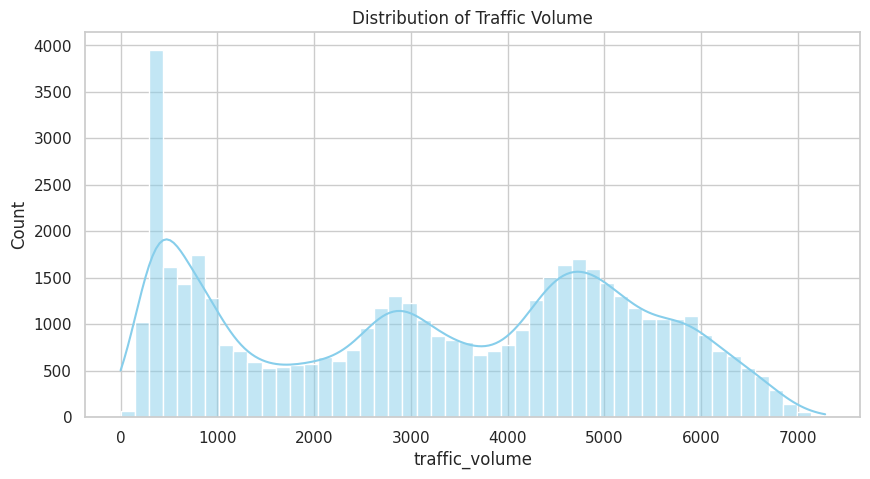

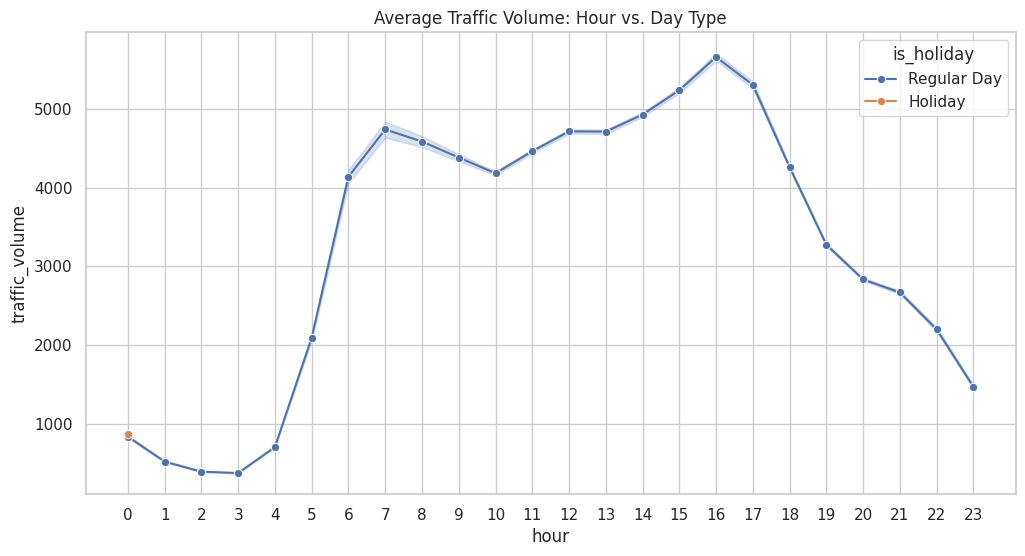

/tmp/ipykernel_14660/2422136594.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_of_week', y='traffic_volume', order=day_order, palette='coolwarm')


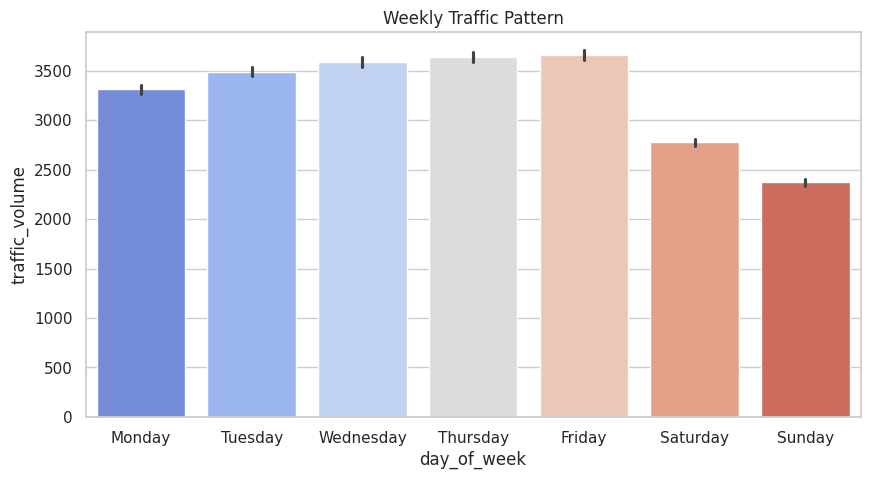

In [ ]:
# Set visual style
sns.set_theme(style="whitegrid")

# Plot 1: Distribution of Traffic Volume
plt.figure(figsize=(10, 5))
sns.histplot(df['traffic_volume'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Traffic Volume')
plt.show()

# Plot 2: Traffic Volume by Hour of Day
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='traffic_volume', hue='is_holiday', marker='o')
plt.title('Average Traffic Volume: Hour vs. Day Type')
plt.xticks(range(0, 24))
plt.show()

# Plot 3: Traffic Volume by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='day_of_week', y='traffic_volume', order=day_order, palette='coolwarm')
plt.title('Weekly Traffic Pattern')
plt.show()

## **Weather and Correlation Analysis**
Analyzing how environmental factors correlate with traffic density.

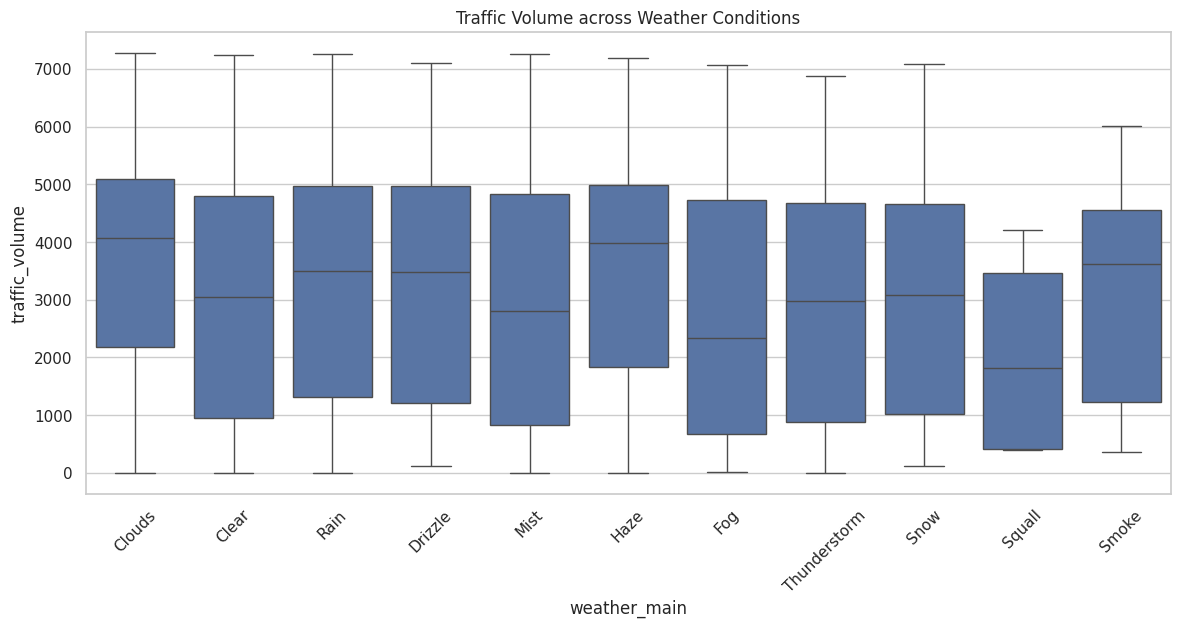

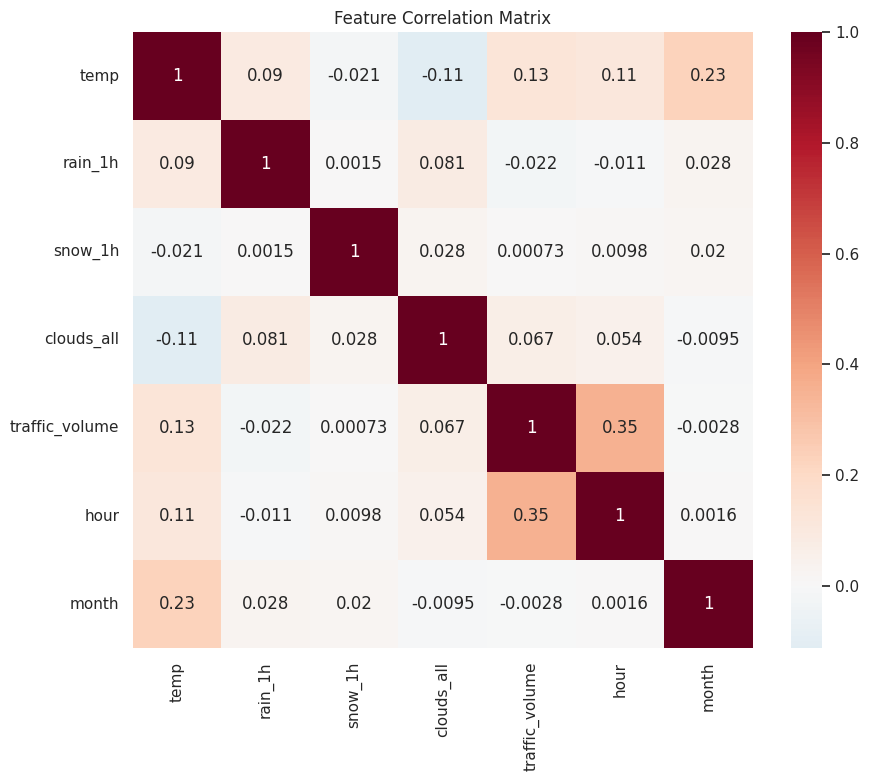

In [ ]:
# Plot 4: Impact of Weather Main Categories
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='weather_main', y='traffic_volume')
plt.title('Traffic Volume across Weather Conditions')
plt.xticks(rotation=45)
plt.show()

# Plot 5: Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'hour', 'month']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,year,is_holiday
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,2012,Regular Day
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,2012,Regular Day
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,2012,Regular Day
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,2012,Regular Day
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,2012,Regular Day


In [ ]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.3 MB/s eta 0:00:00


# **Model Training & Evaluation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Setup Features and Target
# Excluding raw date_time and the target traffic_volume
X = df.drop(columns=['traffic_volume', 'date_time'])
y = df['traffic_volume']

# Identify column types
num_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'month', 'year']
cat_cols = ['holiday', 'weather_main', 'weather_description', 'day_of_week', 'is_holiday']

# 2. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Defining Model**

In [ ]:
from sklearn.linear_model import Ridge

# 3. Define Models (Updated to use Ridge)
models = {
    "Linear Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

## **Training & Evaluating Models**

           Model           MSE          MAE         RMSE        R2
0   Linear Ridge  3.185853e+06  1562.166856  1784.895919  0.190013
1  Random Forest  1.792011e+05   229.152131   423.321534  0.954439
2        XGBoost  1.799645e+05   247.293289   424.222229  0.954245


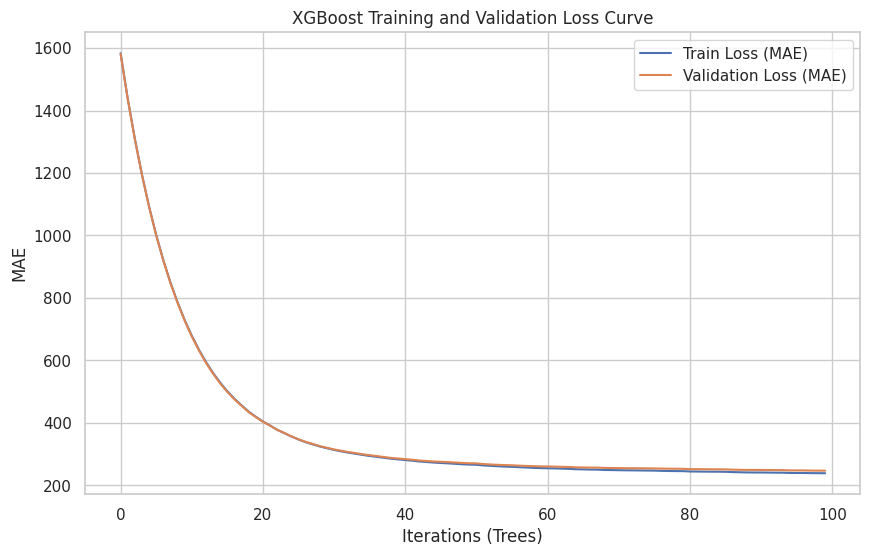

In [ ]:
# 4. Train and Evaluate
results = []

for name, model in models.items():
    # Create a pipeline that preprocesses then fits the model
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Calculate Metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2})

# Display Metrics Table
results_df = pd.DataFrame(results)
print(results_df)

# 5. Plotting Validation Curves (Loss) for XGBoost
# Note: Linear Regression and RF don't use 'epochs' in the same way,
# so we visualize XGBoost's learning progress.
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

xgb_curve = XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae")
xgb_curve.fit(X_train_transformed, y_train, eval_set=[(X_train_transformed, y_train), (X_test_transformed, y_test)], verbose=False)

evals_result = xgb_curve.evals_result()

plt.figure(figsize=(10, 6))
plt.plot(evals_result['validation_0']['mae'], label='Train Loss (MAE)')
plt.plot(evals_result['validation_1']['mae'], label='Validation Loss (MAE)')
plt.title('XGBoost Training and Validation Loss Curve')
plt.xlabel('Iterations (Trees)')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()